# FEDERAL SPENDING ANALYSIS

In [1]:
# Import Library

import pandas as pd
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Import Contract dataset

folder = r"E:\Federal Spending\Contract all"
files = glob.glob(os.path.join(folder, "*.csv"))

df_list = []

for file in files:
    temp = pd.read_csv(file, low_memory=False)
    
    temp["source_file"] = os.path.basename(file)
    
    df_list.append(temp)

# Merge vertically (stack rows)
df1 = pd.concat(df_list, ignore_index=True)

In [3]:
# List of essential columns for analysis

cols_needed_contract = [
    # --- Identifiers ---
    "contract_transaction_unique_key",
    "contract_award_unique_key",
    "award_id_piid",
    "modification_number",
    "transaction_number",
    "action_date",
    "action_date_fiscal_year",

    # --- Spending Amounts ---
    "federal_action_obligation",
    "total_dollars_obligated",
    "total_outlayed_amount_for_overall_award",

    # --- Agency Info ---
    "awarding_agency_name",
    "awarding_sub_agency_name",
    "awarding_office_name",

    # --- Vendor / Recipient Info ---
    "recipient_name",
    "recipient_uei",
    "recipient_country_code",
    "recipient_state_code",
    "recipient_city_name",
    "recipient_state_name",

    # --- Place of Performance (Geography) ---
    "primary_place_of_performance_country_code",
    "primary_place_of_performance_state_code",
    "primary_place_of_performance_city_name",
    "prime_award_transaction_place_of_performance_cd_current",
    'primary_place_of_performance_zip_4', 
    'primary_place_of_performance_county_name', 
    'primary_place_of_performance_state_name',

    # --- Category / Classification ---
    "naics_code",
    "naics_description",
    "product_or_service_code",
    "product_or_service_code_description",

    # --- Award Characteristics ---
    "type_of_contract_pricing",
    "award_type",
    "extent_competed"
]

In [4]:
df_contract = df1[cols_needed_contract].copy()
df_contract.head()

,contract_transaction_unique_key,contract_award_unique_key,award_id_piid,modification_number,transaction_number,action_date,action_date_fiscal_year,federal_action_obligation,total_dollars_obligated,total_outlayed_amount_for_overall_award,...,primary_place_of_performance_zip_4,primary_place_of_performance_county_name,primary_place_of_performance_state_name,naics_code,naics_description,product_or_service_code,product_or_service_code_description,type_of_contract_pricing,award_type,extent_competed
0,1204_-NONE-_123J1921P0022_P00001_-NONE-_0,CONT_AWD_123J1921P0022_1204_-NONE-_-NONE-,123J1921P0022,P00001,0,2024-04-19,2024,-18151.00,0.00,NaN,...,554021219,HENNEPIN,MINNESOTA,611430.0,PROFESSIONAL AND MANAGEMENT DEVELOPMENT TRAINING,6910,TRAINING AIDS,FIRM FIXED PRICE,PURCHASE ORDER,NOT COMPETED
1,1204_-NONE-_123J1923P0010_P00001_-NONE-_0,CONT_AWD_123J1923P0010_1204_-NONE-_-NONE-,123J1923P0010,P00001,0,2023-11-01,2024,0.00,165000.00,158276.50,...,201914359,FAIRFAX,VIRGINIA,621111.0,OFFICES OF PHYSICIANS (EXCEPT MENTAL HEALTH SP...,Q301,MEDICAL- LABORATORY TESTING,FIRM FIXED PRICE,PURCHASE ORDER,NOT COMPETED
2,1204_-NONE-_123J1923P0033_P00001_-NONE-_0,CONT_AWD_123J1923P0033_1204_-NONE-_-NONE-,123J1923P0033,P00001,0,2023-11-06,2024,14542.46,326409.58,372494.52,...,208552620,MONTGOMERY,MARYLAND,541990.0,"ALL OTHER PROFESSIONAL, SCIENTIFIC, AND TECHNI...",R614,SUPPORT- ADMINISTRATIVE: PAPER SHREDDING,FIRM FIXED PRICE,PURCHASE ORDER,NOT COMPETED
3,1204_-NONE-_123J1924P0010_0_-NONE-_0,CONT_AWD_123J1924P0010_1204_-NONE-_-NONE-,123J1924P0010,0,0,2024-07-03,2024,11820.00,11820.00,11820.00,...,641121358,JACKSON,MISSOURI,513210.0,SOFTWARE PUBLISHERS,7A21,IT AND TELECOM - BUSINESS APPLICATION SOFTWARE...,FIRM FIXED PRICE,PURCHASE ORDER,NOT COMPETED
4,1204_-NONE-_123J1924P0018_0_-NONE-_0,CONT_AWD_123J1924P0018_1204_-NONE-_-NONE-,123J1924P0018,0,0,2024-08-27,2024,45639.00,45639.00,45639.00,...,201906274,FAIRFAX,VIRGINIA,541519.0,OTHER COMPUTER RELATED SERVICES,7A21,IT AND TELECOM - BUSINESS APPLICATION SOFTWARE...,FIRM FIXED PRICE,PURCHASE ORDER,FULL AND OPEN COMPETITION AFTER EXCLUSION OF S...


In [5]:
#Number of rows and columns

print('Total rows:', df_contract.shape[0])
print('Total columns:', df_contract.shape[1])

Total rows: 2921859
Total columns: 33


## CLEANING

In [6]:
#Check for duplicates

df_contract[df_contract.duplicated()]

,contract_transaction_unique_key,contract_award_unique_key,award_id_piid,modification_number,transaction_number,action_date,action_date_fiscal_year,federal_action_obligation,total_dollars_obligated,total_outlayed_amount_for_overall_award,...,primary_place_of_performance_zip_4,primary_place_of_performance_county_name,primary_place_of_performance_state_name,naics_code,naics_description,product_or_service_code,product_or_service_code_description,type_of_contract_pricing,award_type,extent_competed


In [7]:
#check for missing values

df_contract.isnull().sum()

contract_transaction_unique_key                                  0
contract_award_unique_key                                        0
award_id_piid                                                    0
modification_number                                              0
transaction_number                                               0
action_date                                                      0
action_date_fiscal_year                                          0
federal_action_obligation                                        0
total_dollars_obligated                                          0
total_outlayed_amount_for_overall_award                    1237857
awarding_agency_name                                             0
awarding_sub_agency_name                                         0
awarding_office_name                                             0
recipient_name                                                  26
recipient_uei                                                 

In [8]:
# Check for missing primary_place_of_performance_state_code

missing_state = df_contract[df_contract["primary_place_of_performance_state_code"].isna()]

missing_state["primary_place_of_performance_country_code"].value_counts().tail(20)

primary_place_of_performance_country_code
COM    5
DMA    4
MAC    4
KIR    4
PRK    4
MTQ    4
GNB    3
IMN    3
LCA    3
KNA    3
BES    3
CYM    3
COK    2
USA    2
ATG    2
IRN    1
LIE    1
ESH    1
HMD    1
XQZ    1
Name: count, dtype: int64

There are two records where the state code is missing even though the country is listed as the United States. All other missing state codes belong to international locations. Therefore, we will identify and correctly populate the two missing U.S. state codes, and we will label all other missing entries as “INTERNATIONAL.”

In [9]:
# Missing USA state's detail

missing_usa = df_contract[
    (df_contract["primary_place_of_performance_state_code"].isna()) &
    (df_contract["primary_place_of_performance_country_code"] == "USA")
]
missing_usa

,contract_transaction_unique_key,contract_award_unique_key,award_id_piid,modification_number,transaction_number,action_date,action_date_fiscal_year,federal_action_obligation,total_dollars_obligated,total_outlayed_amount_for_overall_award,...,primary_place_of_performance_zip_4,primary_place_of_performance_county_name,primary_place_of_performance_state_name,naics_code,naics_description,product_or_service_code,product_or_service_code_description,type_of_contract_pricing,award_type,extent_competed
1843820,3600_-NONE-_36C24120P0563_P00001_-NONE-_0,CONT_AWD_36C24120P0563_3600_-NONE-_-NONE-,36C24120P0563,P00001,0,2020-04-10,2020,0.0,70000.00,NaN,...,906305366,ORANGE,NaN,334516.0,ANALYTICAL LABORATORY INSTRUMENT MANUFACTURING,6640,LABORATORY EQUIPMENT AND SUPPLIES,FIRM FIXED PRICE,PURCHASE ORDER,NOT COMPETED
1928969,1323_-NONE-_DOCYA132316SE0127_P19002_-NONE-_0,CONT_AWD_DOCYA132316SE0127_1323_-NONE-_-NONE-,DOCYA132316SE0127,P19002,0,2020-04-23,2020,0.0,533600.16,NaN,...,H4P2P5,NaN,NaN,811212.0,COMPUTER AND OFFICE MACHINE REPAIR AND MAINTEN...,D319,IT AND TELECOM- ANNUAL SOFTWARE MAINTENANCE SE...,FIRM FIXED PRICE,PURCHASE ORDER,COMPETED UNDER SAP


In [10]:
# Populate and remove the missing values of state code

df_contract.loc[
    (df_contract["award_id_piid"] == "36C24120P0563"),
    "primary_place_of_performance_state_code"
] = "CA"

df_contract = df_contract.drop(df_contract[df_contract['award_id_piid'] == 'DOCYA132316SE0127'].index)

In [11]:
# Check whether the missing values are removed

missing_usa = df_contract[
    (df_contract["primary_place_of_performance_state_code"].isna()) &
    (df_contract["primary_place_of_performance_country_code"] == "USA")
]
missing_usa

,contract_transaction_unique_key,contract_award_unique_key,award_id_piid,modification_number,transaction_number,action_date,action_date_fiscal_year,federal_action_obligation,total_dollars_obligated,total_outlayed_amount_for_overall_award,...,primary_place_of_performance_zip_4,primary_place_of_performance_county_name,primary_place_of_performance_state_name,naics_code,naics_description,product_or_service_code,product_or_service_code_description,type_of_contract_pricing,award_type,extent_competed


In [12]:
missing_state = df_contract[df_contract["primary_place_of_performance_state_code"].isna()]
missing_state.shape

(178745, 33)

Rest of the missing state_code are International

In [13]:
# Populate missing State code as "International"

df_contract["primary_place_of_performance_state_code"] = df_contract["primary_place_of_performance_state_code"].fillna("INTERNATIONAL")

In [14]:
# Populate missing recipient _name as "Unknown_Vendor"

df_contract["recipient_name"] = df_contract["recipient_name"].fillna("UNKNOWN_VENDOR")

In [15]:
df_contract["award_type"] = "Contract"

In [16]:
# Keep only positive obligations (remove de-obligations, adjustments, and zero-dollar awards)

df_contract = df_contract[df_contract["federal_action_obligation"] > 0]

In [17]:
# Verify

df_contract.isnull().sum()

contract_transaction_unique_key                                 0
contract_award_unique_key                                       0
award_id_piid                                                   0
modification_number                                             0
transaction_number                                              0
action_date                                                     0
action_date_fiscal_year                                         0
federal_action_obligation                                       0
total_dollars_obligated                                         0
total_outlayed_amount_for_overall_award                    793591
awarding_agency_name                                            0
awarding_sub_agency_name                                        0
awarding_office_name                                            0
recipient_name                                                  0
recipient_uei                                                   1
recipient_

## ANALYSIS

### What is total spending by agency and fiscal year?

In [18]:
# Total Award Amount (2020-2024)

total_spending = df_contract["federal_action_obligation"].sum()
total_spending_billion = total_spending / 1_000_000_000
print(f"Total Federal Spending (Contract): ${total_spending_billion:,.2f}B")

Total Federal Spending (Contract): $1,138.24B


In [19]:
# Total Award Amount for each fiscal year

total_spending_year = (
    df_contract.groupby("action_date_fiscal_year")["federal_action_obligation"]
    .sum()
    .sort_index()
)

for year, amount in total_spending_year.items():
    amount_billion = amount / 1_000_000_000
    print(f"FY{year} (Contract): ${amount_billion:,.2f}B")

FY2020 (Contract): $198.59B
FY2021 (Contract): $211.84B
FY2022 (Contract): $228.34B
FY2023 (Contract): $246.69B
FY2024 (Contract): $252.77B


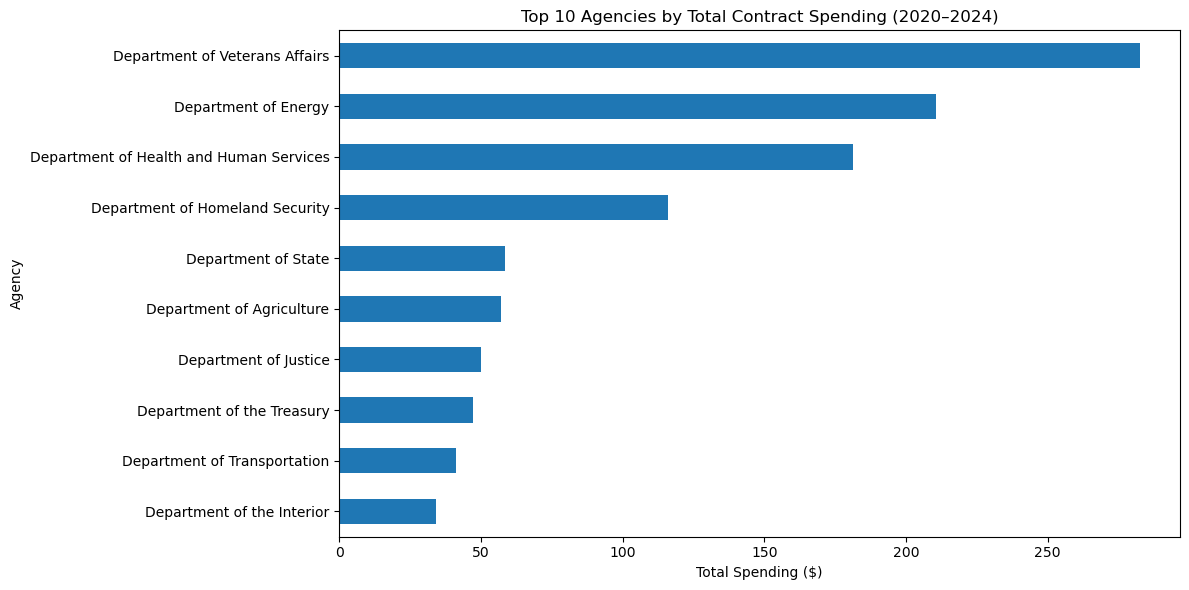

In [20]:
# Top 10 Agencies by Total Contract Spending (2020–2024)

total_by_agency = (
    df_contract.groupby("awarding_agency_name")["federal_action_obligation"]
    .sum()
    .sort_values(ascending=False)
)

# Convert to billions
total_by_agency_billion = (total_by_agency / 1e9)

# Plot
plt.figure(figsize=(12,6))
total_by_agency_billion.head(10).plot(kind="barh")
plt.title("Top 10 Agencies by Total Contract Spending (2020–2024)")
plt.xlabel("Total Spending ($)")
plt.ylabel("Agency")
plt.gca().invert_yaxis() 
plt.tight_layout()
plt.show()

In [21]:
# Aggregate spending

agency_year = (
    df_contract.groupby(["action_date_fiscal_year", "awarding_agency_name"])
    ["federal_action_obligation"]
    .sum()
    .reset_index()
)

agency_year

,action_date_fiscal_year,awarding_agency_name,federal_action_obligation
0,2020,Department of Agriculture,1.253745e+10
1,2020,Department of Commerce,6.114627e+09
2,2020,Department of Education,3.171976e+09
3,2020,Department of Energy,3.610643e+10
4,2020,Department of Health and Human Services,3.682641e+10
...,...,...,...
65,2024,Department of State,1.261454e+10
66,2024,Department of Transportation,9.063192e+09
67,2024,Department of Veterans Affairs,6.948742e+10
68,2024,Department of the Interior,8.698163e+09


In [22]:
# Spending by Agency and Fiscal Year

# Pivot table
pivot = agency_year.pivot_table(
    index="awarding_agency_name",
    columns="action_date_fiscal_year",
    values="federal_action_obligation",
    aggfunc="sum",
    fill_value=0
)
pivot

action_date_fiscal_year,2020,2021,2022,2023,2024
awarding_agency_name,,,,,
Department of Agriculture,1.253745e+10,1.008816e+10,1.042491e+10,1.184558e+10,1.212898e+10
Department of Commerce,6.114627e+09,4.818014e+09,4.367305e+09,5.303337e+09,5.542426e+09
Department of Education,3.171976e+09,2.741077e+09,2.512929e+09,2.630753e+09,2.989993e+09
Department of Energy,3.610643e+10,3.890592e+10,4.174445e+10,4.549209e+10,4.843442e+10
Department of Health and Human Services,3.682641e+10,3.610515e+10,3.807077e+10,3.652165e+10,3.376646e+10
Department of Homeland Security,2.051839e+10,2.196504e+10,2.253635e+10,2.533020e+10,2.553547e+10
Department of Housing and Urban Development,1.243427e+09,1.380708e+09,9.086555e+08,1.054734e+09,2.120990e+09
Department of Justice,9.587089e+09,1.008241e+10,9.423847e+09,1.085821e+10,1.026334e+10
Department of Labor,2.275355e+09,2.480878e+09,2.478811e+09,2.820477e+09,2.413463e+09


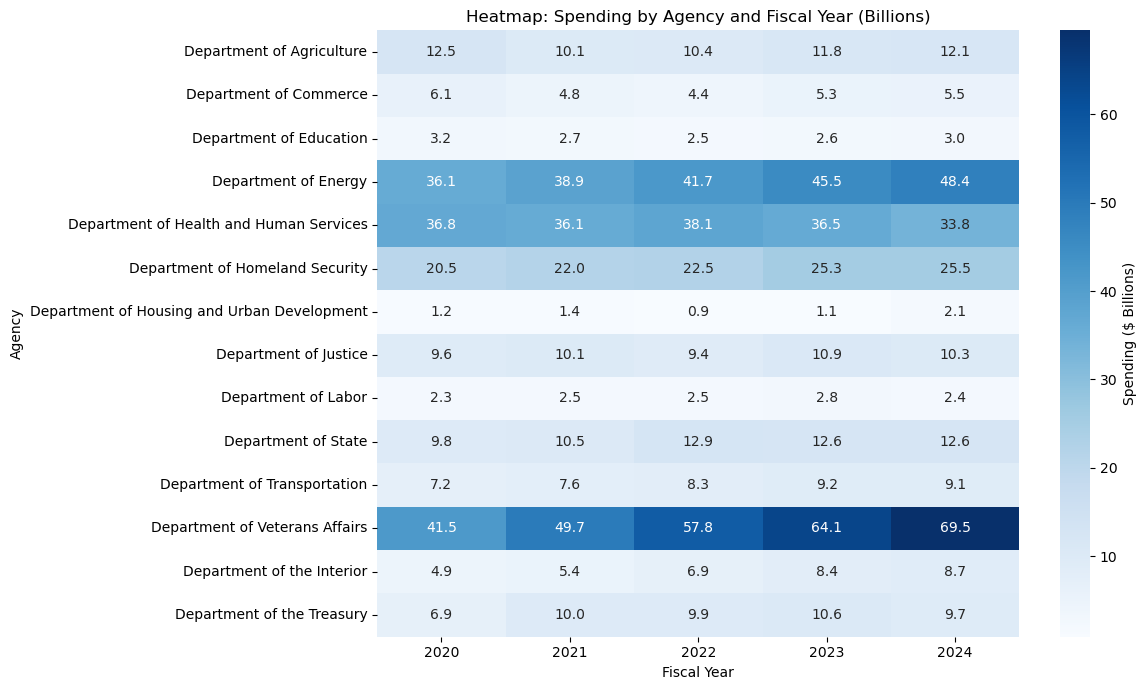

In [23]:
# Convert to billions before plotting
pivot_billion = pivot / 1e9

plt.figure(figsize=(12, 7))

sns.heatmap(
    pivot_billion,
    cmap="Blues",
    annot=True,                
    fmt=".1f",                 
    cbar_kws={"label": "Spending ($ Billions)"}
)

# Plot
plt.title("Heatmap: Spending by Agency and Fiscal Year (Billions)")
plt.xlabel("Fiscal Year")
plt.ylabel("Agency")
plt.tight_layout()
plt.show()

## Which contractors receive the most federal funding?

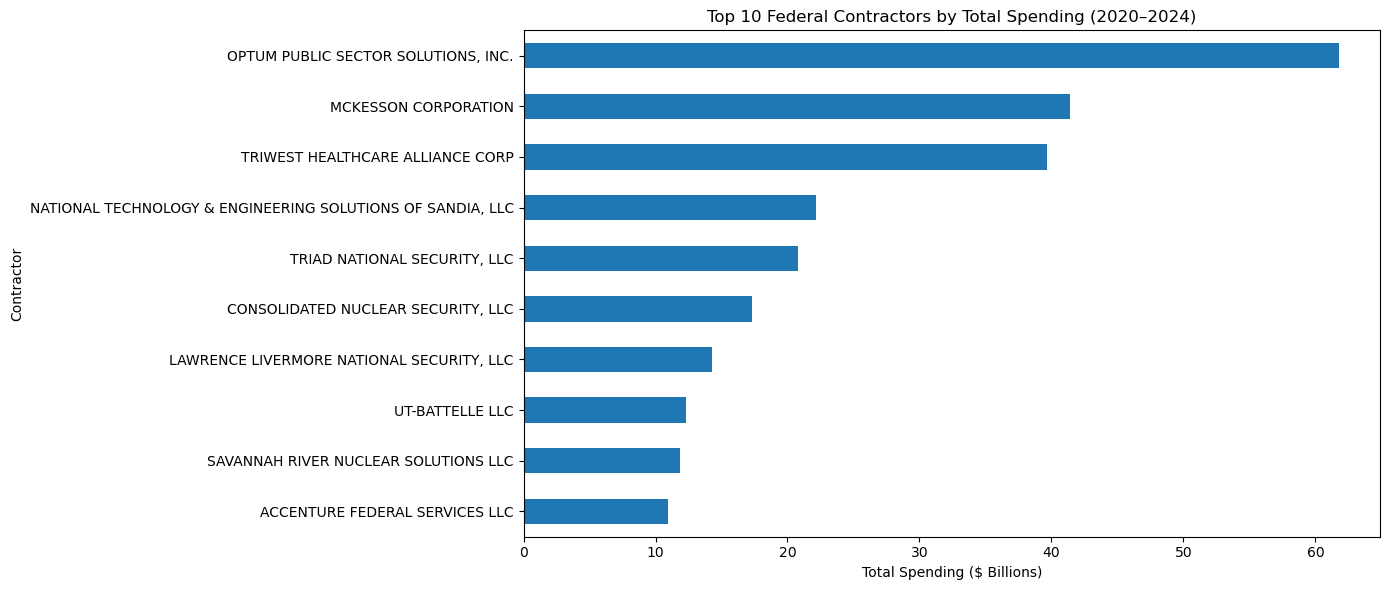

In [24]:
# Calculate Total Federal Spending by Contractor (2020–2024)

# Group contracts by recipient (vendor) and sum the obligations
vendor_spending = (
    df_contract.groupby("recipient_name")["federal_action_obligation"]
    .sum()
    .sort_values(ascending=False)
)

# Convert to billions for readability in plots
vendor_spending_billion = vendor_spending / 1e9

# Plot
plt.figure(figsize=(14,6))
vendor_spending_billion.head(10).plot(kind="barh")
plt.title("Top 10 Federal Contractors by Total Spending (2020–2024)")
plt.xlabel("Total Spending ($ Billions)")
plt.ylabel("Contractor")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
# Vendor Concentration (HHI)

# Calculate market share of each vendor
vendor_market_share = vendor_spending / vendor_spending.sum()

# Compute HHI (sum of squared market shares)
hhi = (vendor_market_share ** 2).sum()

print("Vendor Concentration (HHI):", hhi)

Vendor Concentration (HHI): 0.008147007577294063


In [26]:
# Vendor spending by fiscal year

vendor_year = (
    df_contract.groupby(["action_date_fiscal_year", "recipient_name"])
    ["federal_action_obligation"]
    .sum()
    .reset_index()
)
vendor_year

,action_date_fiscal_year,recipient_name,federal_action_obligation
0,2020,"""E"" SECURITY, LLC",156880.00
1,2020,"""MARY MILLS & ASSOCIATES, LLC""",297500.00
2,2020,"""MIBURA, INC.""",3990.00
3,2020,#1 AUTO TECH GROUP INC.,52715.40
4,2020,"'ANIID SURFACES, LLC",13781.00
...,...,...,...
256279,2024,ZYDZIK EDWARD,9997.80
256280,2024,ZYGIEL BROS CONSTRUCTION,109911.00
256281,2024,ZYLSTRA JORDAN JAMES,24901.00
256282,2024,ZYMO RESEARCH CORPORATION,46415.00


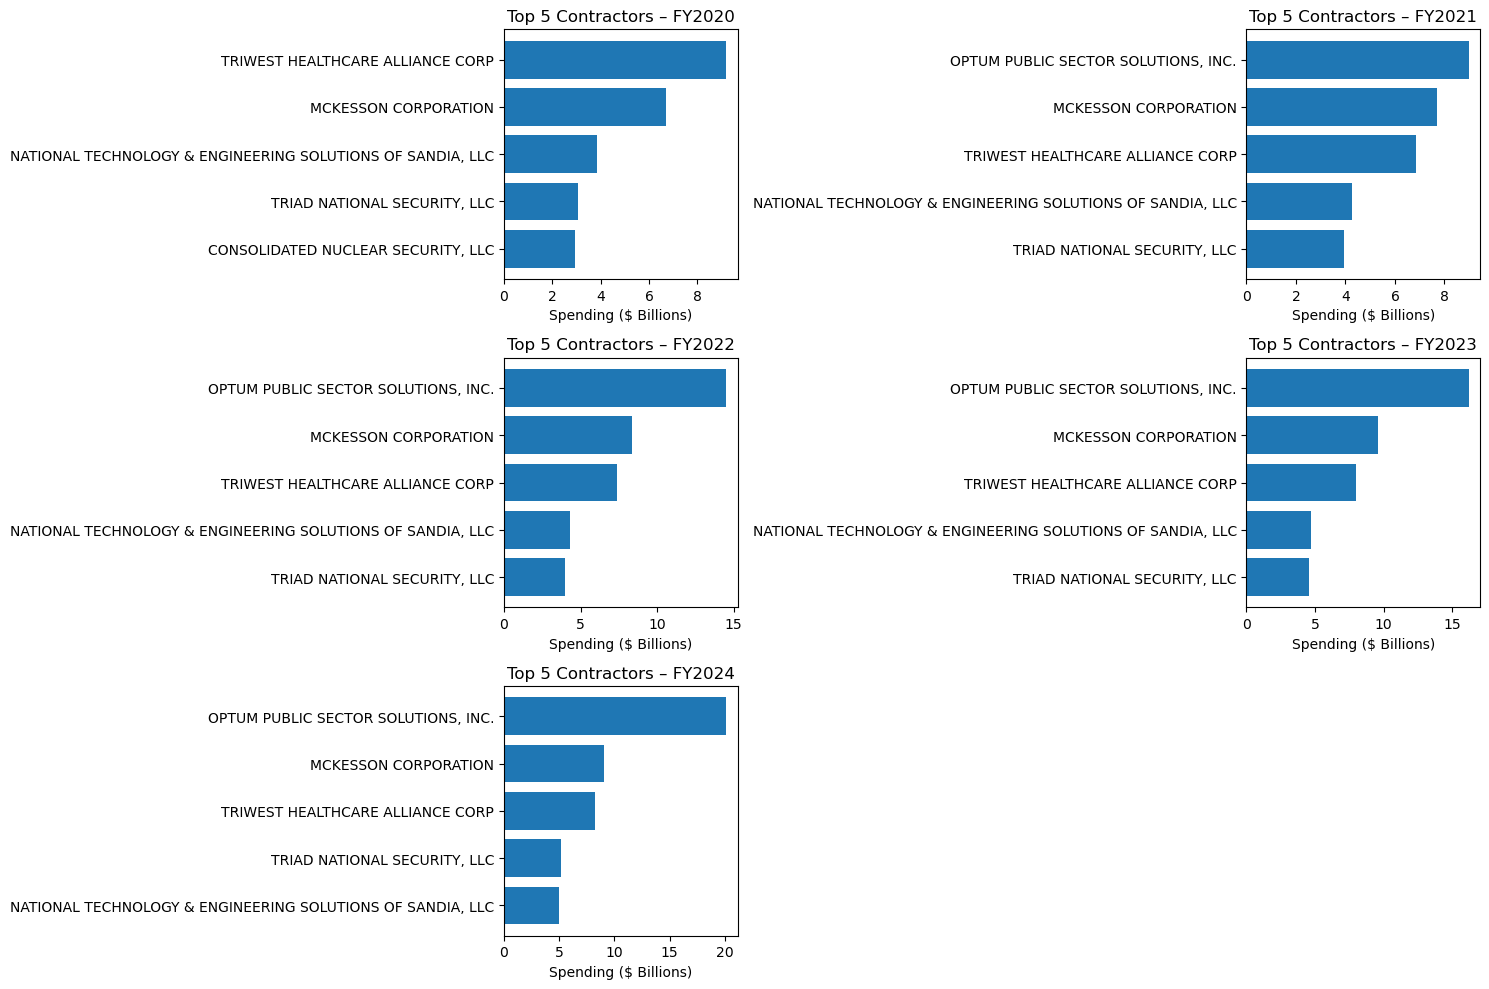

In [27]:
# Get Top 5 Vendors for Each Fiscal Year

# Then pick the top 5 vendors for each fiscal year.
top5_per_year = vendor_year.sort_values(
    ["action_date_fiscal_year", "federal_action_obligation"],
    ascending=[True, False]
).groupby("action_date_fiscal_year").head(5)

# List of fiscal years in sorted order (2020–2024)
years = sorted(df_contract["action_date_fiscal_year"].unique())

# Plot Top 5 Contractors for Each Year (5 small horizontal charts)
plt.figure(figsize=(15, 10))

for i, yr in enumerate(years, 1):
    plt.subplot(3, 2, i)  # 3 rows × 2 columns grid (5 plots)
    
    temp = top5_per_year[top5_per_year["action_date_fiscal_year"] == yr]
    
    # Convert to billions for readability
    amounts = temp["federal_action_obligation"] / 1e9

    # Plot
    plt.barh(temp["recipient_name"], amounts)
    plt.title(f"Top 5 Contractors – FY{yr}")
    plt.xlabel("Spending ($ Billions)")
    plt.gca().invert_yaxis()  # Largest at top

plt.tight_layout()
plt.show()


#### Insights – Vendor Ranking & Market Concentration (2020–2024)

Federal contract spending from 2020–2024 is distributed across a large and diverse vendor base. The top contractors include large healthcare service providers such as Optum Public Sector Solutions, pharmaceutical distributors like McKesson Corporation, and major national security or nuclear technology vendors such as TriWest Healthcare Alliance, Consolidated Nuclear Security, and Lawrence Livermore National Security.
While the annual top-5 charts show strong year-to-year dominance by healthcare and national security contractors, the overall vendor market is not highly concentrated. The market concentration index (HHI = 81.47, on a 0–10,000 scale) indicates a highly competitive vendor environment, where no single contractor commands a significant share of total federal obligations. This aligns with the federal procurement model, which spans thousands of contractors across healthcare, defense, logistics, and technology.

## What drives spending concentration in certain states or sectors?

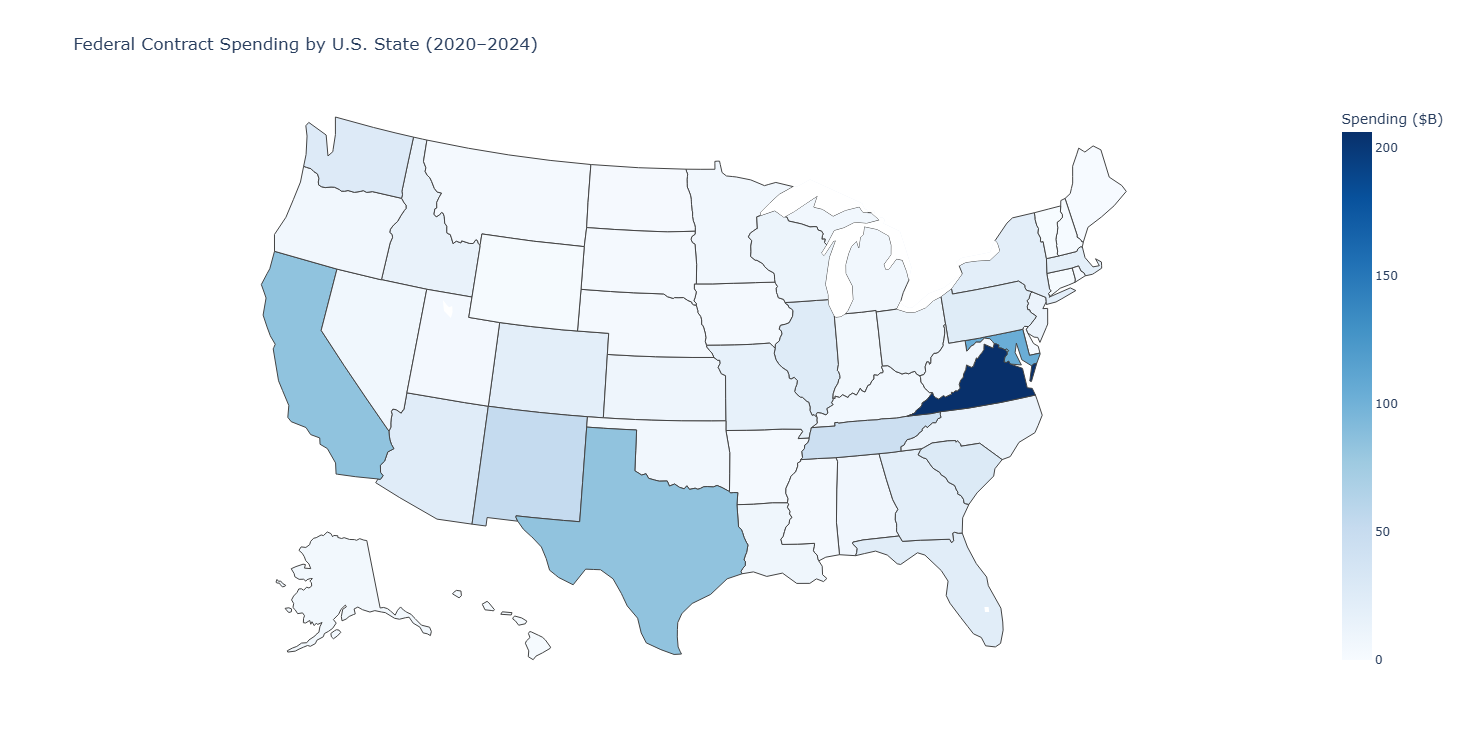

In [55]:
# Federal Contract Spending by U.S. State (2020–2024)

# Aggregate spending by state
state_spending = (
    df_contract.groupby("primary_place_of_performance_state_code")
    ["federal_action_obligation"]
    .sum()
    .reset_index()
)

state_spending["spending_billion"] = state_spending["federal_action_obligation"] / 1e9

# Remove International (state code = "INTERNATIONAL")
state_spending = state_spending[state_spending["primary_place_of_performance_state_code"].str.len() == 2]

# Choropleth map
fig = px.choropleth(
    state_spending,
    locations="primary_place_of_performance_state_code",
    locationmode="USA-states",
    color="spending_billion",
    color_continuous_scale="Blues",
    scope="usa",
    labels={"spending_billion": "Spending ($B)"},
    title="Federal Contract Spending by U.S. State (2020–2024)"
)

fig.update_layout(width=1300, height=750)
fig.show()

In [29]:
def hhi_vendor(group):
    vendor_totals = (
        group.groupby("recipient_name")["federal_action_obligation"].sum()
    )
    shares = vendor_totals / vendor_totals.sum()
    return (shares ** 2).sum() * 10_000

state_vendor_hhi = (
    df_contract
    .groupby("primary_place_of_performance_state_code")
    .apply(hhi_vendor)
    .reset_index(name="vendor_hhi")
)

state_vendor_hhi.sort_values("vendor_hhi", ascending=False).head(10)

,primary_place_of_performance_state_code,vendor_hhi
11,FM,5477.477220
39,NV,3925.389696
16,ID,3743.315462
20,KS,3647.624106
38,NM,3429.735003
34,ND,3247.588868
26,MH,2970.290414
29,MO,2960.723458
4,AZ,2898.858832
46,PW,2623.553051


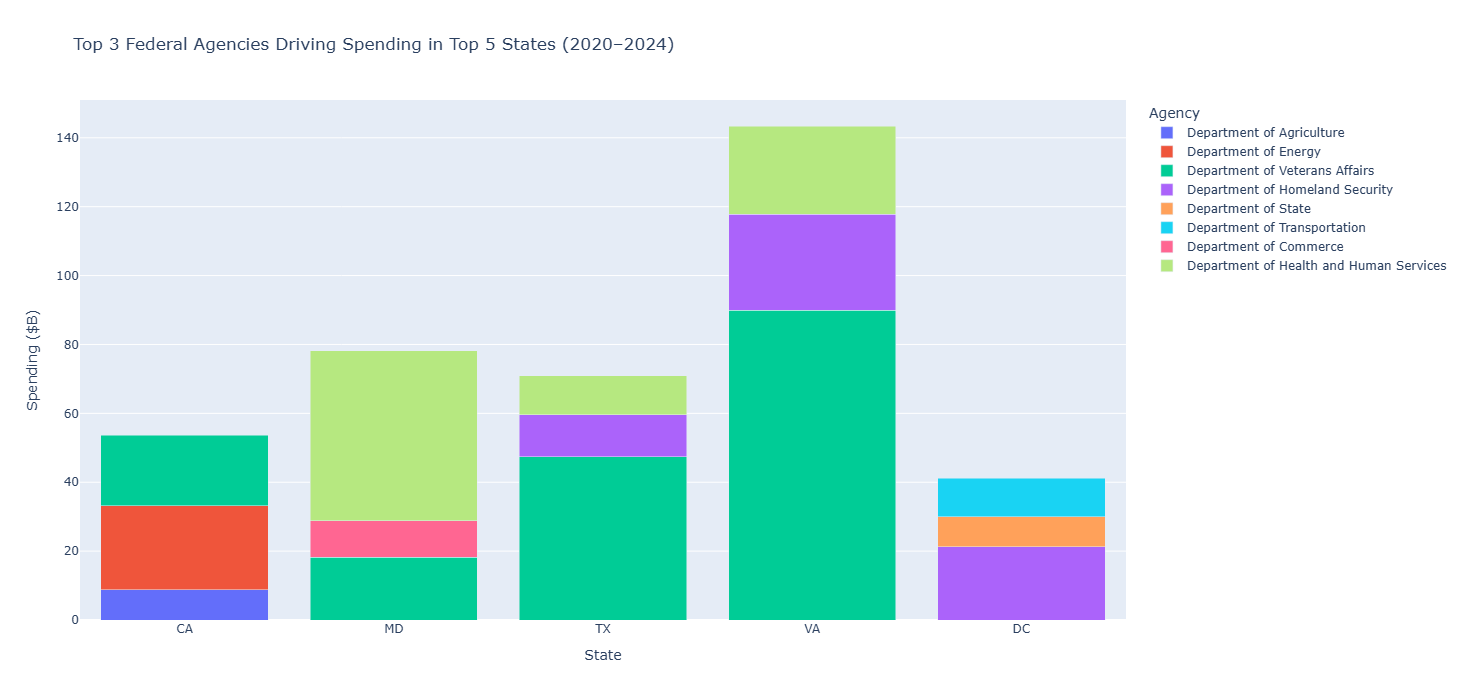

In [30]:
# Aggregate total spending by state
state_totals = (
    df_contract
    .groupby("primary_place_of_performance_state_code")["federal_action_obligation"]
    .sum()
    .reset_index()
)

# Keep only valid US states
state_totals = state_totals[
    state_totals["primary_place_of_performance_state_code"].str.len() == 2
]

# Top 5 states by spending
top_states = (
    state_totals
    .sort_values("federal_action_obligation", ascending=False)
    .head(5)["primary_place_of_performance_state_code"]
)

# Filter to top states
df_top_states = df_contract[
    df_contract["primary_place_of_performance_state_code"].isin(top_states)
]

# Aggregate by State × Agency
state_agency_spending = (
    df_top_states
    .groupby(
        ["primary_place_of_performance_state_code", "awarding_agency_name"]
    )["federal_action_obligation"]
    .sum()
    .reset_index()
)

# Keep TOP 3 agencies per state
state_agency_spending["rank"] = (
    state_agency_spending
    .groupby("primary_place_of_performance_state_code")["federal_action_obligation"]
    .rank(method="first", ascending=False)
)

state_agency_top3 = state_agency_spending[
    state_agency_spending["rank"] <= 3
].copy()

# Convert to billions
state_agency_top3["spending_billion"] = (
    state_agency_top3["federal_action_obligation"] / 1e9
)

# Stacked bar chart
fig = px.bar(
    state_agency_top3,
    x="primary_place_of_performance_state_code",
    y="spending_billion",
    color="awarding_agency_name",
    title="Top 3 Federal Agencies Driving Spending in Top 5 States (2020–2024)",
    labels={
        "primary_place_of_performance_state_code": "State",
        "spending_billion": "Spending ($B)",
        "awarding_agency_name": "Awarding Agency"
    }
)

fig.update_layout(
    barmode="stack",
    width=1200,
    height=700,
    legend_title_text="Agency"
)

fig.show()


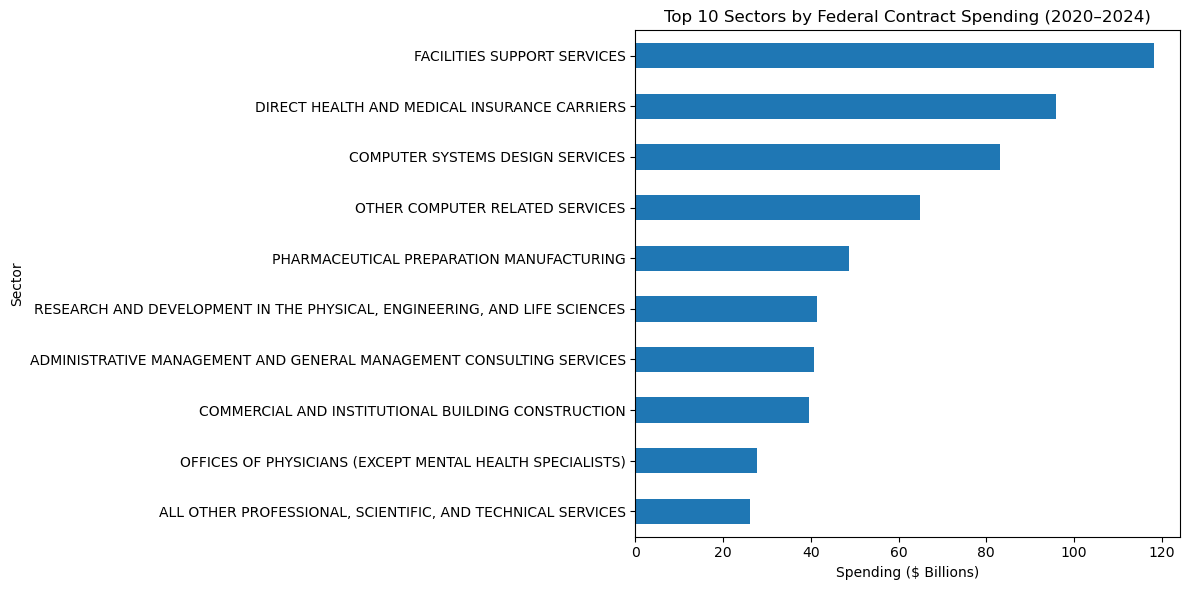

In [31]:
# Calculate Federal Contract Spending by NAICS Sector (2020–2024)

# Group data by NAICS sector description and sum obligations
sector_spending = (
    df_contract.groupby("naics_description")
    ["federal_action_obligation"]
    .sum()
    .sort_values(ascending=False)
)

# Convert to billions for cleaner visualization
sector_spending_billion = sector_spending / 1e9

# Plot
plt.figure(figsize=(12,6))
sector_spending_billion.head(10).plot(kind="barh")
plt.title("Top 10 Sectors by Federal Contract Spending (2020–2024)")
plt.xlabel("Spending ($ Billions)")
plt.ylabel("Sector")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [32]:
# Sector-level spending concentration

def hhi_sector(group):
    sector_totals = (
        group.groupby("naics_description")["federal_action_obligation"].sum()
    )
    shares = sector_totals / sector_totals.sum()
    return (shares ** 2).sum() * 10_000

state_sector_hhi = (
    df_contract
    .groupby("primary_place_of_performance_state_code")
    .apply(hhi_sector)
    .reset_index(name="sector_hhi")
)

state_sector_hhi.sort_values("sector_hhi", ascending=False).head(10)

,primary_place_of_performance_state_code,sector_hhi
38,NM,7315.485276
11,FM,5451.884390
50,TN,4414.627450
39,NV,3967.271208
16,ID,3833.259611
20,KS,3695.855512
29,MO,3154.173051
26,MH,2920.663305
4,AZ,2872.133318
3,AS,2655.853702


#### Insights – Geographic & Sector Concentration (2020–2024)

Federal contract spending between 2020 and 2024 is highly concentrated both geographically and structurally. A small group of states—led by Virginia, Texas, Maryland, California, and Washington, D.C.—accounts for a disproportionate share of total obligations, with Virginia alone exceeding $200B in contract spending. Concentration is driven primarily by agency mission alignment, as a limited number of agencies dominate spending within top states, and by strong vendor dependency, evidenced by high vendor Herfindahl–Hirschman Index (HHI) values exceeding 3,000 in states such as New Mexico (HHI ≈ 3,430), Nevada (≈ 3,925), and Idaho (≈ 3,743). Sector-level analysis further reveals significant specialization, with sector HHI values above 7,300 in New Mexico and over 4,400 in Tennessee, indicating reliance on a narrow set of industries. Overall, federal spending concentration is amplified by large, high-value contracts awarded to a small number of vendors operating within specialized sectors, reflecting structural procurement design rather than broad geographic or economic distribution.


## How do contracts compare to grants in terms of dollar amounts and recipient concentration?

In [33]:
# Import Grants dataset

folder = r"E:\Federal Spending\Grand all"
files = glob.glob(os.path.join(folder, "*.csv"))

df_list = []

for file in files:
    temp = pd.read_csv(file, low_memory=False)
    
    # Optional: Add filename so you know which file it came from
    temp["source_file"] = os.path.basename(file)
    
    df_list.append(temp)

# Merge vertically (stack rows)
df_grants = pd.concat(df_list, ignore_index=True)

In [34]:
df_grants.head()

,assistance_transaction_unique_key,assistance_award_unique_key,award_id_fain,modification_number,award_id_uri,sai_number,federal_action_obligation,total_obligated_amount,total_outlayed_amount_for_overall_award,indirect_cost_federal_share_amount,...,highly_compensated_officer_3_name,highly_compensated_officer_3_amount,highly_compensated_officer_4_name,highly_compensated_officer_4_amount,highly_compensated_officer_5_name,highly_compensated_officer_5_amount,usaspending_permalink,initial_report_date,last_modified_date,source_file
0,12BC_AO212501X443G002_-NONE-_10.443_0001,ASST_NON_AO212501X443G002_012,AO212501X443G002,0001,NaN,SAI EXEMPT,0.00,594301.00,516451.19,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/ASST_NON_AO2...,2024-07-22,2024-07-22,Assistance_PrimeTransactions_2025-11-19_H18M05...
1,12BC_AO212501X443G015_-NONE-_10.443_0001,ASST_NON_AO212501X443G015_012,AO212501X443G015,0001,NaN,SAI EXEMPT,0.00,623189.00,167906.02,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/ASST_NON_AO2...,2024-07-22,2024-07-22,Assistance_PrimeTransactions_2025-11-19_H18M05...
2,12C2_15DG11083150002_-NONE-_10.680_0004,ASST_NON_15DG11083150002_012,15DG11083150002,0004,NaN,SAI EXEMPT,-136.43,119863.57,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/ASST_NON_15D...,2024-07-22,2024-07-22,Assistance_PrimeTransactions_2025-11-19_H18M05...
3,12C2_18DG11120107025_-NONE-_10.676_0006,ASST_NON_18DG11120107025_012,18DG11120107025,0006,NaN,SAI EXEMPT,-896.53,78103.47,78103.47,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/ASST_NON_18D...,2024-02-21,2024-02-21,Assistance_PrimeTransactions_2025-11-19_H18M05...
4,12C2_19DG11062765741_-NONE-_10.674_0003,ASST_NON_19DG11062765741_012,19DG11062765741,0003,NaN,SAI EXEMPT,-102579.00,146421.00,146421.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,https://www.usaspending.gov/award/ASST_NON_19D...,2023-11-20,2023-11-20,Assistance_PrimeTransactions_2025-11-19_H18M05...


In [35]:
#check for missing values

print(df_grants["federal_action_obligation"].isna().sum())
print(df_grants["recipient_name"].isna().sum())

0
0


In [36]:
# Keep only positive obligations (remove de-obligations, adjustments, and zero-dollar awards)

df_grants = df_grants[df_grants["federal_action_obligation"] > 0]

In [37]:
# Total Award Amount (2020-2024)

total_spending_contract = df_contract["federal_action_obligation"].sum()
total_spending_billion = total_spending_contract / 1_000_000_000
print(f"Total Federal Spending (Contract): ${total_spending_billion:,.2f}B")

# Total Award Amount (2020-2024)

total_spending_grants = df_grants["federal_action_obligation"].sum()
total_spending_billion = total_spending_grants / 1_000_000_000
print(f"Total Federal Spending (Grants): ${total_spending_billion:,.2f}B")

Total Federal Spending (Contract): $1,138.24B
Total Federal Spending (Grants): $6,073.20B


Contracts vs Grants Spending Comparison (2020–2024)


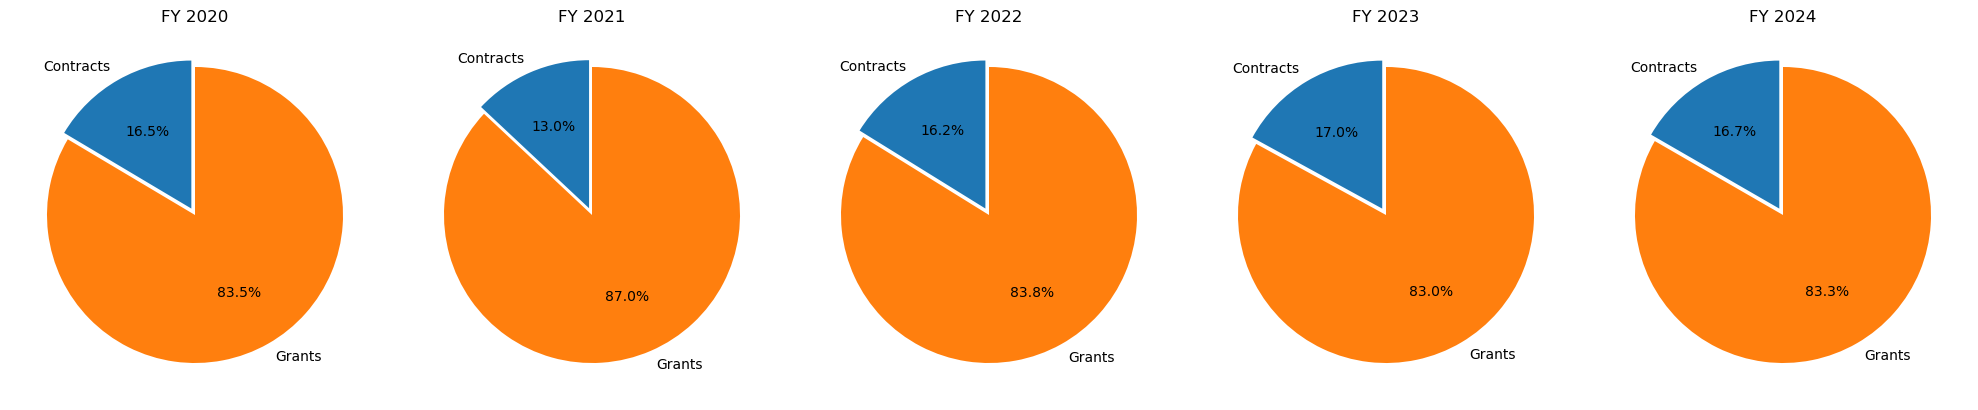

In [38]:
# Contracts vs Grants Spending Comparison (2020–2024)

# Aggregate total contract spending per fiscal year
contracts_year = (
    df_contract.groupby("action_date_fiscal_year")["federal_action_obligation"]
    .sum()
)

# Aggregate total grant spending per fiscal year
grants_year = (
    df_grants.groupby("action_date_fiscal_year")["federal_action_obligation"]
    .sum()
)

# Combine both into one DataFrame for easier plotting
compare_year = pd.DataFrame({
    "Contracts": contracts_year,
    "Grants": grants_year
})

print("Contracts vs Grants Spending Comparison (2020–2024)")

# Fiscal years list (e.g., 2020–2024)
years = compare_year.index.tolist()

# Create 5 side-by-side pie charts (one for each fiscal year)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, year in enumerate(years):
    sizes = compare_year.loc[year] / 1e9  
    labels = ["Contracts", "Grants"]
    
    axes[i].pie(
        sizes,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90,
        explode=[0.05, 0]  
    )
    axes[i].set_title(f"FY {int(year)}")

plt.tight_layout()
plt.show()


In [39]:
# Contract recipient spending
contract_recipient_spending = (
    df_contract.groupby("recipient_name")["federal_action_obligation"]
    .sum()
)

# Market share for each contractor
contract_market_share = contract_recipient_spending / contract_recipient_spending.sum()

# HHI calculation
contract_hhi = (contract_market_share ** 2).sum()

print("Contract Recipient HHI:", contract_hhi)


Contract Recipient HHI: 0.008147007577294061


In [40]:
# Grants recipient spending
grant_recipient_spending = (
    df_grants.groupby("recipient_name")["federal_action_obligation"]
    .sum()
)

# Market share
grant_market_share = grant_recipient_spending / grant_recipient_spending.sum()

# HHI calculation
grant_hhi = (grant_market_share ** 2).sum()

print("Grant Recipient HHI:", grant_hhi)


Grant Recipient HHI: 0.016132603380543693


## Which agencies show the highest spending growth or budget risk?

In [41]:
# Calculate Year-over-Year (YoY) Spending Growth for Each Agency

agency_year["yoy_growth"] = (
    agency_year.groupby("awarding_agency_name")["federal_action_obligation"]
    .pct_change()
)
agency_year["yoy_growth"]

0          NaN
1          NaN
2          NaN
3          NaN
4          NaN
        ...   
65    0.004638
66   -0.010899
67    0.083965
68    0.037824
69   -0.086443
Name: yoy_growth, Length: 70, dtype: float64

In [42]:
# Extract the Latest Year-over-Year Growth per Agency (2023-2024)

latest_growth = (
    agency_year
    .sort_values(["awarding_agency_name", "action_date_fiscal_year"])
    .groupby("awarding_agency_name")
    .tail(1)[["awarding_agency_name", "yoy_growth"]]
    .sort_values("yoy_growth", ascending=False)
)
latest_growth["yoy_growth"] = (latest_growth["yoy_growth"] * 100).round(2).astype(str) + "%"

latest_growth

,awarding_agency_name,yoy_growth
62,Department of Housing and Urban Development,101.09%
58,Department of Education,13.66%
67,Department of Veterans Affairs,8.4%
59,Department of Energy,6.47%
57,Department of Commerce,4.51%
68,Department of the Interior,3.78%
56,Department of Agriculture,2.39%
61,Department of Homeland Security,0.81%
65,Department of State,0.46%
66,Department of Transportation,-1.09%


In [43]:
# Calculate Average Year-over-Year Growth for Each Agency

avg_growth = (
    agency_year.groupby("awarding_agency_name")["yoy_growth"]
    .mean()
    .sort_values(ascending=False)
)
avg_growth = (avg_growth * 100).round(2).astype(str) + "%"
avg_growth

awarding_agency_name
Department of Housing and Urban Development    23.51%
Department of the Interior                     16.03%
Department of Veterans Affairs                 13.85%
Department of the Treasury                     10.92%
Department of Energy                            7.62%
Department of State                             6.84%
Department of Transportation                    6.13%
Department of Homeland Security                 5.71%
Department of Justice                           2.09%
Department of Labor                             2.08%
Department of Agriculture                      -0.04%
Department of Education                        -0.89%
Department of Commerce                         -1.15%
Department of Health and Human Services        -2.03%
Name: yoy_growth, dtype: object

In [54]:
# Budget Risk

agency_mean = (
    agency_year.groupby("awarding_agency_name")["federal_action_obligation"]
    .mean()
)

agency_std = (
    agency_year.groupby("awarding_agency_name")["federal_action_obligation"]
    .std()
)

agency_cv = ((agency_std / agency_mean)*100).sort_values(ascending=False)

risk_cv_df = pd.DataFrame({
    "mean_spending": agency_mean,
    "volatility_std": agency_std,
    "cv_relative_risk": agency_cv
})

risk_cv_df = risk_cv_df.sort_values("cv_relative_risk", ascending=False)
risk_cv_df

risk_cv_df_display = risk_cv_df.copy()

# Convert to billions and format
risk_cv_df_display["mean_spending"] = (
    risk_cv_df_display["mean_spending"] / 1e9
).round(2).astype(str) + " B"

risk_cv_df_display["volatility_std"] = (
    risk_cv_df_display["volatility_std"] / 1e9
).round(2).astype(str) + " B"

# Format CV as percentage
risk_cv_df_display["cv_relative_risk"] = (
    risk_cv_df_display["cv_relative_risk"]
).round(2).astype(str) + " %"

risk_cv_df_display

,mean_spending,volatility_std,cv_relative_risk
awarding_agency_name,,,
Department of Housing and Urban Development,1.34 B,0.47 B,35.12 %
Department of the Interior,6.86 B,1.71 B,24.95 %
Department of Veterans Affairs,56.51 B,11.18 B,19.78 %
Department of the Treasury,9.41 B,1.47 B,15.64 %
Department of Commerce,5.23 B,0.67 B,12.83 %
Department of State,11.7 B,1.41 B,12.04 %
Department of Energy,42.14 B,4.95 B,11.74 %
Department of Transportation,8.27 B,0.88 B,10.62 %
Department of Education,2.81 B,0.27 B,9.56 %


The Department of Housing and Urban Development (HUD) stands out as both the fastest-growing and most budget-volatile agency, with recent year-over-year spending growth exceeding 100%, an average annual growth rate of 23.5%, and the highest budget risk (CV ≈ 35%), indicating significant funding instability.

The Department of the Interior and the Department of Veterans Affairs also exhibit elevated budget risk, with high long-term growth and substantial year-to-year volatility driven by disaster response, infrastructure, and healthcare spending.

In contrast, Health and Human Services (HHS), despite having one of the largest budgets, shows low budget risk (CV ≈ 4%) and modest or negative growth, reflecting a stable and predictable funding structure.

In [67]:
df_contract.to_csv("combined_contracts_2020_2024.csv", index=False)